In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("german_credit_data.csv")

In [3]:
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
995,995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good
996,996,40,male,3,own,little,little,3857,30,car,good
997,997,38,male,2,own,little,NaN,804,12,radio/TV,good
998,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [4]:
df.describe(include = "all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1000.0,NaN,NaN,NaN,499.5,288.819436,0.0,249.75,499.5,749.25,999.0
Age,1000.0,NaN,NaN,NaN,35.546,11.375469,19.0,27.0,33.0,42.0,75.0
Sex,1000,2,male,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job,1000.0,NaN,NaN,NaN,1.904,0.653614,0.0,2.0,2.0,2.0,3.0
Housing,1000,3,own,713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Saving accounts,817,4,little,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Checking account,606,3,little,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Credit amount,1000.0,NaN,NaN,NaN,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
Duration,1000.0,NaN,NaN,NaN,20.903,12.058814,4.0,12.0,18.0,24.0,72.0
Purpose,1000,8,car,337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
 10  Risk              1000 non-null   object
dtypes: int64(5), object(6)
memory usage: 86.1+ KB


In [6]:
df.isna().sum(0)

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [9]:
df["Job"].unique()

array([2, 1, 3, 0])

In [10]:
df = df.dropna().reset_index(drop = True)
df

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,4,53,male,2,free,little,little,4870,24,car,bad
3,7,35,male,3,rent,little,moderate,6948,36,car,good
4,9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...,...
517,989,48,male,1,own,little,moderate,1743,24,radio/TV,good
518,993,30,male,3,own,little,little,3959,36,furniture/equipment,good
519,996,40,male,3,own,little,little,3857,30,car,good
520,998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [11]:
df.drop(columns = "Unnamed: 0", inplace = True)

In [12]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

Text(0.5, 0.98, 'Histograms of Age, Credit Amount and Duration')

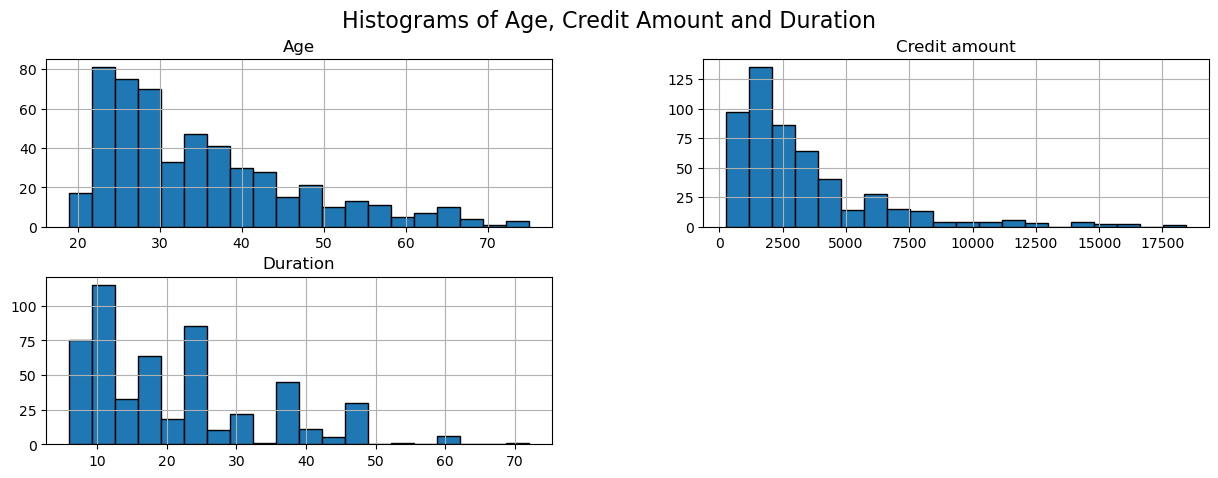

In [13]:
df[["Age", "Credit amount", "Duration"]].hist(bins = 20, edgecolor = "black", figsize = (15, 5))
plt.suptitle("Histograms of Age, Credit Amount and Duration", fontsize = 16)

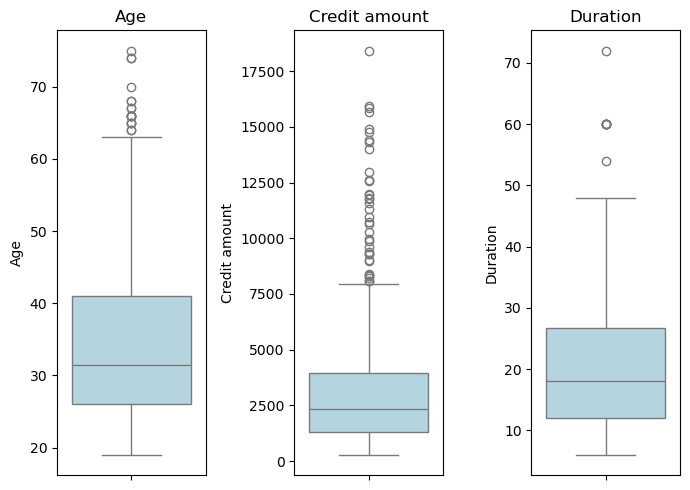

In [14]:
plt.figure(figsize = (7, 5))
for i, col in enumerate(["Age", "Credit amount", "Duration"]):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y = df[col], color = "lightblue")
    plt.title(col)
    
plt.tight_layout()
plt.show()

In [15]:
df.query("Duration >= 60")

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
18,63,male,2,own,little,little,6836,60,business,bad
176,24,female,3,own,moderate,moderate,7408,60,car,bad
199,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
358,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad
378,27,male,3,own,little,moderate,14027,60,car,bad
489,42,male,2,free,little,moderate,6288,60,education,bad
507,36,male,2,rent,little,little,7297,60,business,bad


In [16]:
categorical_cols = df.select_dtypes(include = "object").columns

In [17]:
categorical_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose',
       'Risk'],
      dtype='object')

C:\Users\ACER\AppData\Local\Temp\ipykernel_36336\2295383120.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x = col, palette = "Set2", order = df[col].value_counts().index)
C:\Users\ACER\AppData\Local\Temp\ipykernel_36336\2295383120.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x = col, palette = "Set2", order = df[col].value_counts().index)
C:\Users\ACER\AppData\Local\Temp\ipykernel_36336\2295383120.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x = col, palette = "Set2", order = df[col]

C:\Users\ACER\AppData\Local\Temp\ipykernel_36336\2295383120.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x = col, palette = "Set2", order = df[col].value_counts().index)
C:\Users\ACER\AppData\Local\Temp\ipykernel_36336\2295383120.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x = col, palette = "Set2", order = df[col].value_counts().index)
C:\Users\ACER\AppData\Local\Temp\ipykernel_36336\2295383120.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = df, x = col, palette = "Set2", order = df[col]

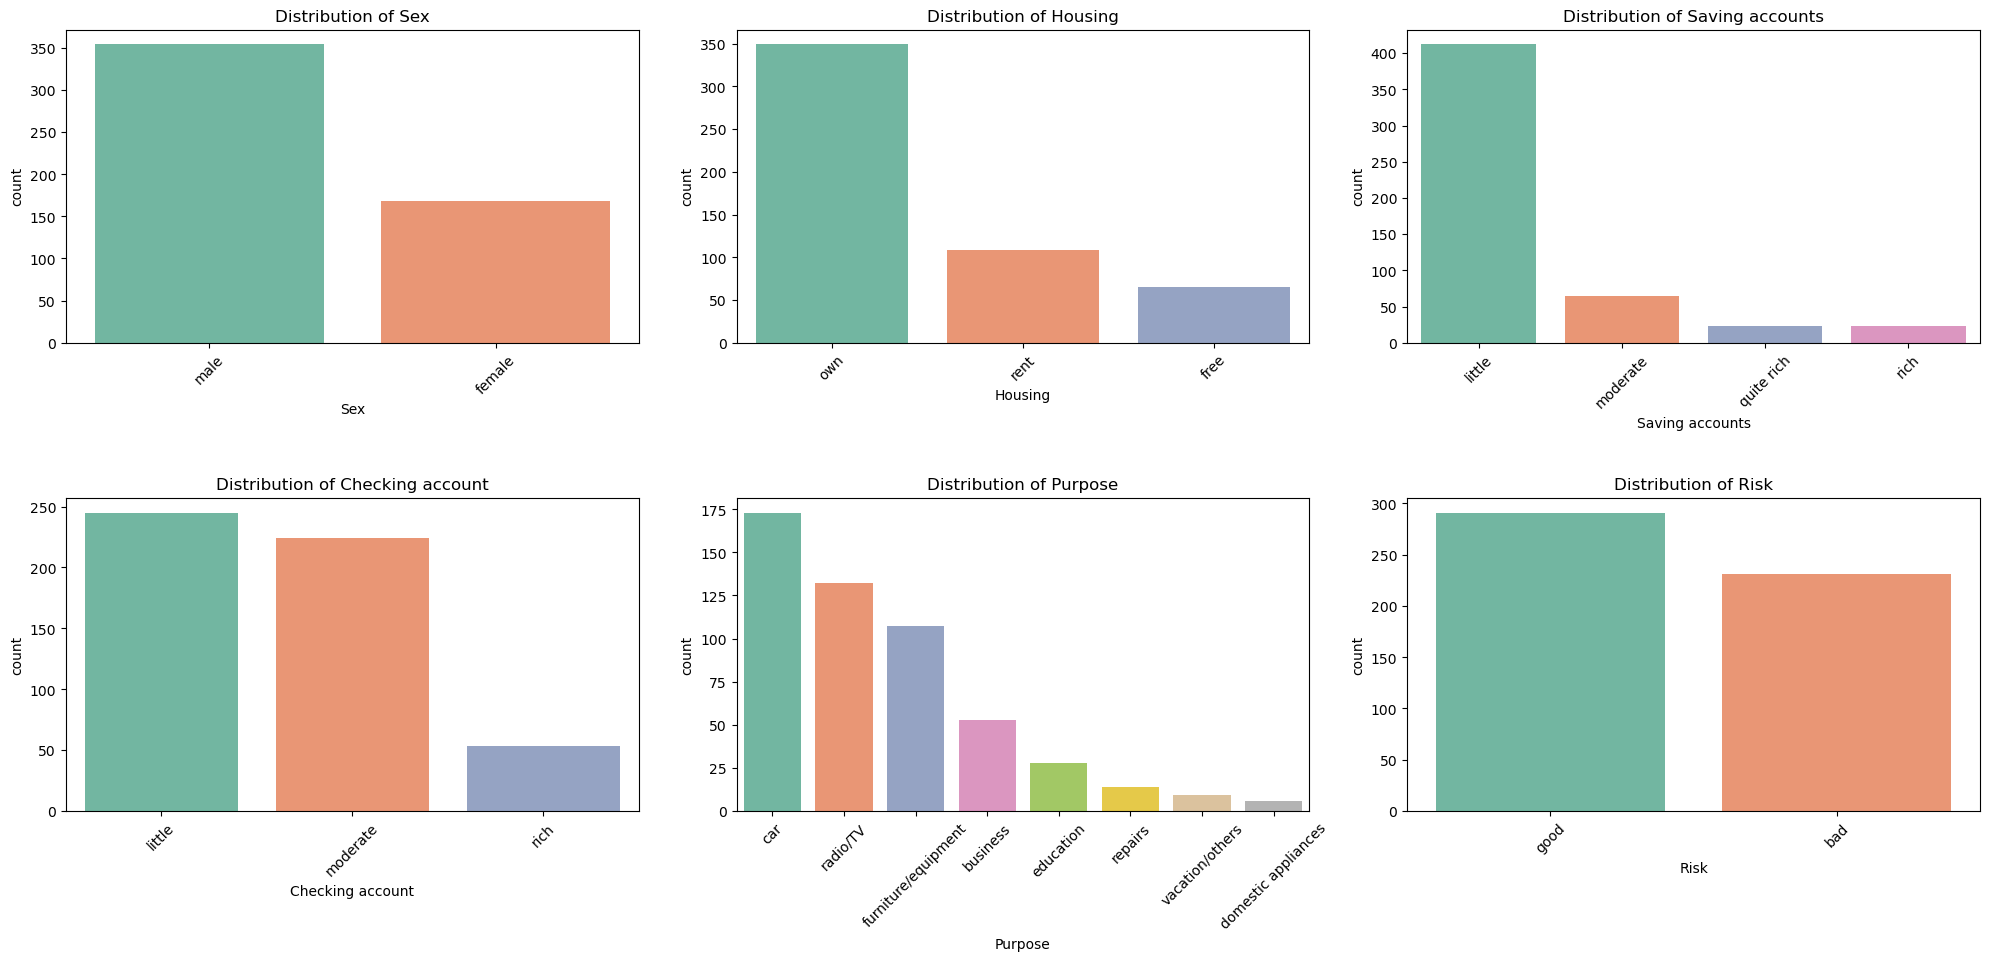

In [18]:
plt.figure(figsize = (20, 13))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1)
    sns.countplot(data = df, x = col, palette = "Set2", order = df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation = 45)
    
plt.tight_layout()
plt.show()

In [19]:
corr = df[["Age", "Job", "Credit amount", "Duration"]].corr()
corr

,Age,Job,Credit amount,Duration
Age,1.000000,0.039771,0.082014,0.001549
Job,0.039771,1.000000,0.334721,0.200794
Credit amount,0.082014,0.334721,1.000000,0.613298
Duration,0.001549,0.200794,0.613298,1.000000


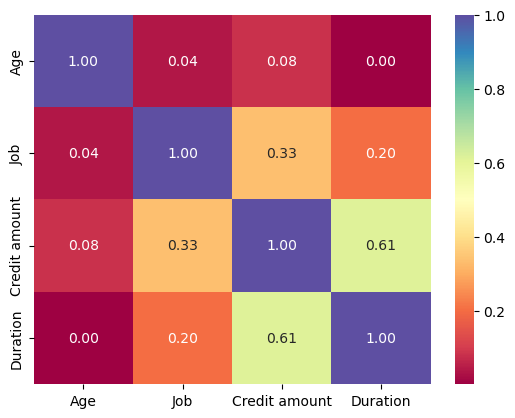

In [20]:
sns.heatmap(corr, annot = True, cmap = "Spectral", fmt = ".2f")
plt.show()

In [21]:
df.groupby("Job")["Credit amount"].mean().sort_values(ascending = False)

Job
3    5648.784810
2    3129.130990
1    2250.715517
0    1767.857143
Name: Credit amount, dtype: float64

In [22]:
df.groupby("Sex")["Credit amount"].mean().sort_values(ascending = False)

Sex
male      3440.833333
female    2937.202381
Name: Credit amount, dtype: float64

In [23]:
pd.pivot_table(df, values = "Credit amount", index = "Housing", columns = "Purpose")

Purpose,business,car,domestic appliances,education,furniture/equipment,radio/TV,repairs,vacation/others
Housing,,,,,,,,
free,4705.000000,5180.314286,NaN,5314.250000,4419.444444,2097.000000,1190.0,7842.666667
own,3725.973684,3120.485437,1333.5,2625.076923,3031.100000,2307.613861,2993.5,10321.833333
rent,6180.833333,3398.285714,NaN,2627.857143,2890.285714,2138.000000,2384.0,NaN


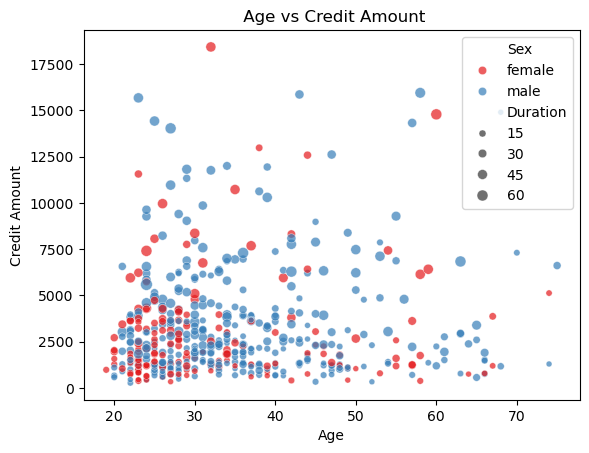

In [24]:
sns.scatterplot(data = df, x = "Age", y = "Credit amount", hue = "Sex", size = "Duration", alpha = 0.7, palette = "Set1")
plt.title(" Age vs Credit Amount")
plt.xlabel("Age")
plt.ylabel("Credit Amount")
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_36336\3964066512.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data = df, x = "Saving accounts", y = "Credit amount", palette = "Set2")


Text(0, 0.5, 'Credit Amount')

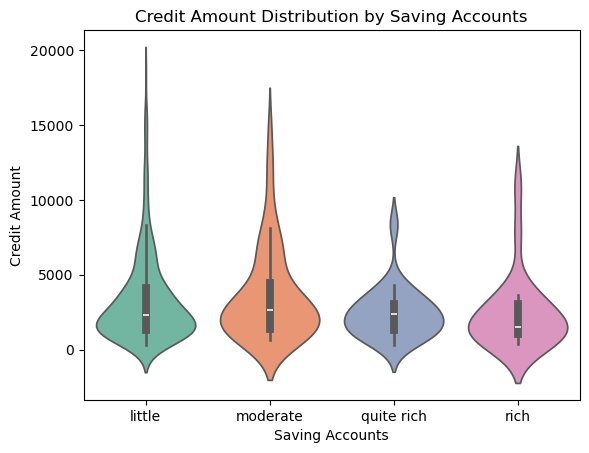

In [25]:
sns.violinplot(data = df, x = "Saving accounts", y = "Credit amount", palette = "Set2")
plt.title("Credit Amount Distribution by Saving Accounts")
plt.xlabel("Saving Accounts")
plt.ylabel("Credit Amount")

In [26]:
df["Risk"].value_counts(normalize = True)*100

Risk
good    55.747126
bad     44.252874
Name: proportion, dtype: float64

C:\Users\ACER\AppData\Local\Temp\ipykernel_36336\1156273165.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df,x = "Risk" ,y = col, palette = "Pastel2")
C:\Users\ACER\AppData\Local\Temp\ipykernel_36336\1156273165.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df,x = "Risk" ,y = col, palette = "Pastel2")
C:\Users\ACER\AppData\Local\Temp\ipykernel_36336\1156273165.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df,x = "Risk" ,y = col, palette = "Pastel2")


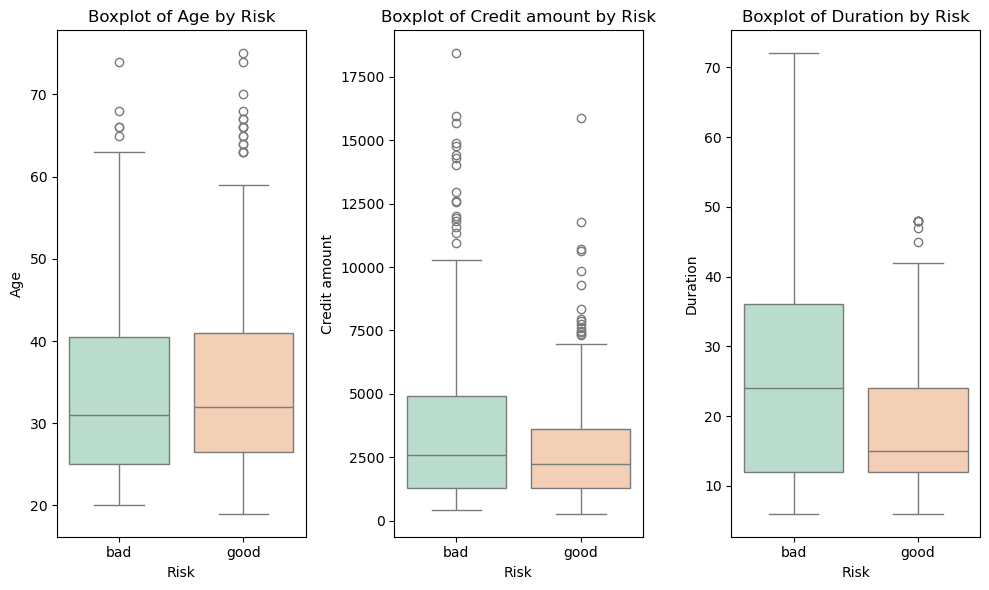

In [27]:
plt.figure(figsize = (10, 6))
for i, col in enumerate(["Age", "Credit amount", "Duration"]):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(data = df,x = "Risk" ,y = col, palette = "Pastel2")
    plt.title(f"Boxplot of {col} by Risk")

plt.tight_layout()
plt.show()

In [28]:
df.groupby("Risk")[["Age", "Credit amount", "Duration"]].mean()

,Age,Credit amount,Duration
Risk,,,
bad,34.147186,3881.090909,25.445887
good,35.477663,2800.594502,18.079038


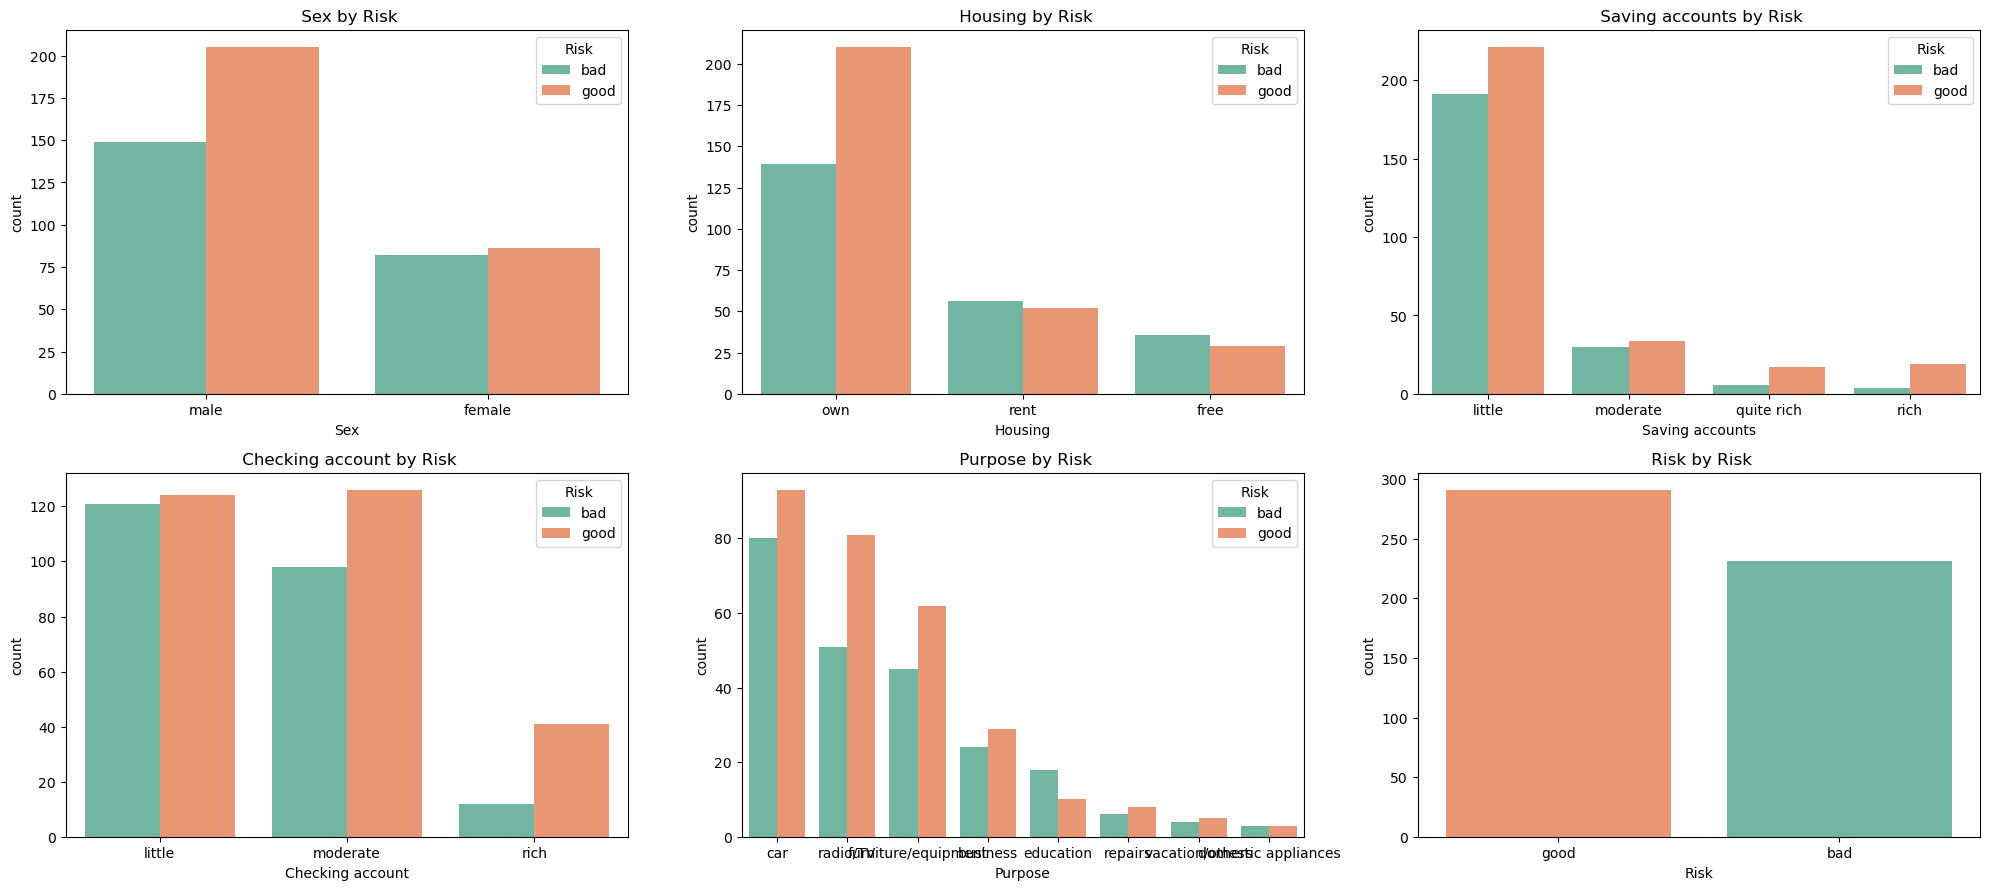

In [29]:
plt.figure(figsize = (20, 13))  
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1)
    sns.countplot(data = df, x = col, hue = "Risk", palette = "Set2", order = df[col].value_counts().index)
    plt.title(f" {col} by Risk")
    
plt.tight_layout()
plt.show()

In [30]:
df.columns

Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [31]:
features = ['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
            'Credit amount', 'Duration', 'Purpose']

In [32]:
target = "Risk"

In [33]:
df_model = df[features + [target]].copy()

In [34]:
df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,22,female,2,own,little,moderate,5951,48,radio/TV,bad
1,45,male,2,free,little,little,7882,42,furniture/equipment,good
2,53,male,2,free,little,little,4870,24,car,bad
3,35,male,3,rent,little,moderate,6948,36,car,good
4,28,male,3,own,little,moderate,5234,30,car,bad


In [35]:
from sklearn.preprocessing import LabelEncoder
import joblib

In [36]:
cat_cols = df_model.select_dtypes(include = "object").columns.drop(target)
cat_cols

Index(['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose'], dtype='object')

In [37]:
le_dict = {}

for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le
    joblib.dump(le, f"{col}_label_encoder.pkl")

df_model.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,22,0,2,1,0,1,5951,48,5,bad
1,45,1,2,0,0,0,7882,42,4,good
2,53,1,2,0,0,0,4870,24,1,bad
3,35,1,3,2,0,1,6948,36,1,good
4,28,1,3,1,0,1,5234,30,1,bad


In [38]:
le_target = LabelEncoder()
df_model[target] = le_target.fit_transform(df_model[target])
df_model[target].value_counts()

Risk
1    291
0    231
Name: count, dtype: int64

In [39]:
joblib.dump(le_target, "target_label_encoder.pkl")
print("Target classes (0/1 mapping):", list(le_target.classes_))

Target classes (0/1 mapping): ['bad', 'good']


In [40]:
from sklearn.model_selection import train_test_split

In [41]:
X = df_model[features]
y = df_model[target]

In [42]:
X.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,22,0,2,1,0,1,5951,48,5
1,45,1,2,0,0,0,7882,42,4
2,53,1,2,0,0,0,4870,24,1
3,35,1,3,2,0,1,6948,36,1
4,28,1,3,1,0,1,5234,30,1


In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (417, 9)  Test shape: (105, 9)


In [44]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV

In [45]:
def train_model(model, param_grid, X_train, y_train, X_test, y_test):
    grid = GridSearchCV(model, param_grid, cv = 5, scoring = "accuracy", n_jobs = -1, error_score = "raise")
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    return best_model, acc, grid.best_params_, y_pred

In [46]:
results = {}
trained_models = {}

In [47]:
dt = DecisionTreeClassifier(random_state = 1, class_weight = "balanced")
dt_param_grid = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

best_dt, dt_acc, dt_best_params, dt_pred = train_model(dt, dt_param_grid, X_train, y_train, X_test, y_test)
results["Decision Tree"] = dt_acc
trained_models["Decision Tree"] = best_dt

print("Decision Tree accuracy:", dt_acc)
print("Best params:", dt_best_params)
print(classification_report(y_test, dt_pred, target_names = le_target.classes_))

Decision Tree accuracy: 0.6
Best params: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
              precision    recall  f1-score   support

         bad       0.54      0.63      0.58        46
        good       0.67      0.58      0.62        59

    accuracy                           0.60       105
   macro avg       0.60      0.60      0.60       105
weighted avg       0.61      0.60      0.60       105



In [48]:
rf = RandomForestClassifier(random_state = 1, class_weight = "balanced")
rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

best_rf, rf_acc, rf_best_params, rf_pred = train_model(rf, rf_param_grid, X_train, y_train, X_test, y_test)
results["Random Forest"] = rf_acc
trained_models["Random Forest"] = best_rf

print("Random Forest accuracy:", rf_acc)
print("Best params:", rf_best_params)
print(classification_report(y_test, rf_pred, target_names = le_target.classes_))

Random Forest accuracy: 0.6666666666666666
Best params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
              precision    recall  f1-score   support

         bad       0.63      0.59      0.61        46
        good       0.69      0.73      0.71        59

    accuracy                           0.67       105
   macro avg       0.66      0.66      0.66       105
weighted avg       0.66      0.67      0.67       105



In [49]:
et = ExtraTreesClassifier(random_state = 1, class_weight = "balanced")
et_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

best_et, et_acc, et_best_params, et_pred = train_model(et, et_param_grid, X_train, y_train, X_test, y_test)
results["Extra Trees"] = et_acc
trained_models["Extra Trees"] = best_et

print("Extra Trees accuracy:", et_acc)
print("Best params:", et_best_params)
print(classification_report(y_test, et_pred, target_names = le_target.classes_))

Extra Trees accuracy: 0.6095238095238096
Best params: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
              precision    recall  f1-score   support

         bad       0.55      0.57      0.56        46
        good       0.66      0.64      0.65        59

    accuracy                           0.61       105
   macro avg       0.60      0.60      0.60       105
weighted avg       0.61      0.61      0.61       105



In [50]:
xgb = XGBClassifier(random_state = 1, eval_metric = "logloss")
xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2]
}

best_xgb, xgb_acc, xgb_best_params, xgb_pred = train_model(xgb, xgb_param_grid, X_train, y_train, X_test, y_test)
results["XGBoost"] = xgb_acc
trained_models["XGBoost"] = best_xgb

print("XGBoost accuracy:", xgb_acc)
print("Best params:", xgb_best_params)
print(classification_report(y_test, xgb_pred, target_names = le_target.classes_))

XGBoost accuracy: 0.6666666666666666
Best params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}
              precision    recall  f1-score   support

         bad       0.62      0.61      0.62        46
        good       0.70      0.71      0.71        59

    accuracy                           0.67       105
   macro avg       0.66      0.66      0.66       105
weighted avg       0.67      0.67      0.67       105



In [51]:
results_df = pd.DataFrame(list(results.items()), columns = ["Model", "Accuracy"]).sort_values("Accuracy", ascending = False)
results_df

,Model,Accuracy
1,Random Forest,0.666667
3,XGBoost,0.666667
2,Extra Trees,0.609524
0,Decision Tree,0.600000


C:\Users\ACER\AppData\Local\Temp\ipykernel_36336\3753750205.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = results_df, x = "Model", y = "Accuracy", palette = "Set2")


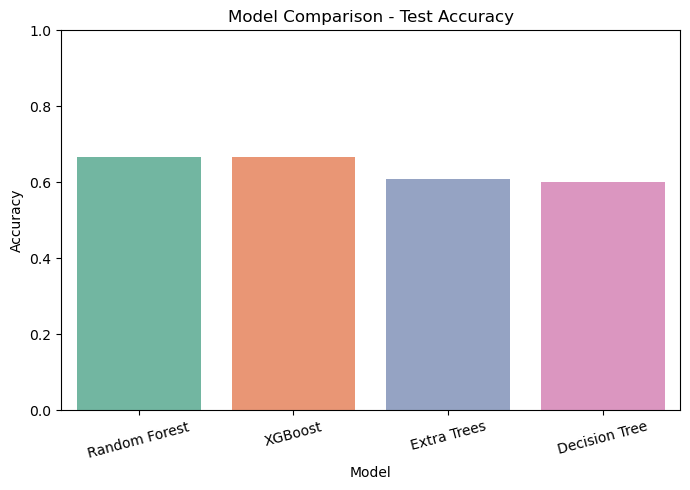

In [52]:
plt.figure(figsize = (7, 5))
sns.barplot(data = results_df, x = "Model", y = "Accuracy", palette = "Set2")
plt.title("Model Comparison - Test Accuracy")
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.xticks(rotation = 15)
plt.tight_layout()
plt.show()

In [53]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print(f"Best model: {best_model_name} (accuracy = {results[best_model_name]:.4f})")

Best model: Random Forest (accuracy = 0.6667)


              precision    recall  f1-score   support

         bad       0.63      0.59      0.61        46
        good       0.69      0.73      0.71        59

    accuracy                           0.67       105
   macro avg       0.66      0.66      0.66       105
weighted avg       0.66      0.67      0.67       105



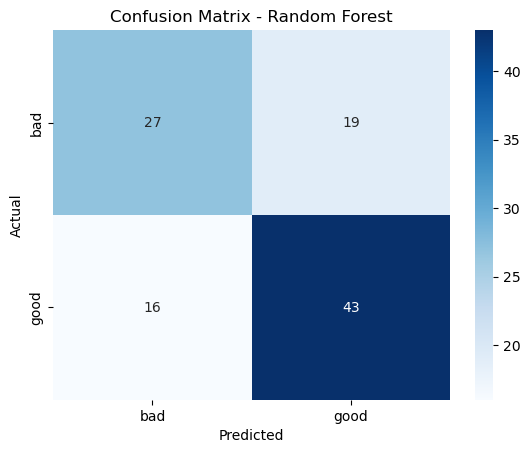

In [54]:
y_pred_best = best_model.predict(X_test)

print(classification_report(y_test, y_pred_best, target_names = le_target.classes_))

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues",
            xticklabels = le_target.classes_, yticklabels = le_target.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

In [55]:
joblib.dump(best_model, "best_model.pkl")
print(f"Saved best model ({best_model_name}) to best_model.pkl")

Saved best model (Random Forest) to best_model.pkl
